Импорт бибилиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error, r2_score

Загрузка данных о домах

In [ ]:
df = pd.read_csv("boston.csv")

print(f"Размеры таблицы: {df.shape[0]} домов и {df.shape[1]} параметров")

crime_to_price = df.groupby("CRIM")["MEDV"].median()
print("\nМедианная стоимость (тысяч $) в зависимости от уровня преступности:\n", crime_to_price)

df.head(3)


Размеры таблицы: 506 домов и 14 параметров

Медианная стоимость (тысяч $) в зависимости от уровня преступности:
 CRIM
0.00632     24.0
0.00906     32.2
0.01096     22.0
0.01301     32.7
0.01311     35.4
            ... 
45.74610     7.0
51.13580    15.0
67.92080     5.0
73.53410     8.8
88.97620    10.4
Name: MEDV, Length: 504, dtype: float64


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


В этом блоке были получены размеры таблицы. Видно, что дома в районах с более низким уровнем преступности обладают в среднем более выской медианной стомостью.  Затем мы получили 3 записи из датасета, демонстирующие параметры домов: уровень преступности в районе, земля под застройку, производящая промышленность в районе, наличие выхода к реке, концентрация оксидов азота, количество комнат, возраст зданий, дистанция до центров трудоустройства, выход к шоссе, налог, соотношение учеников и учителей в районе, доля чёрного населения, доля населения низшего статуса.

Кодирование и масштабирование

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head(3)

x = df.drop("MEDV", axis = 1)
y = df['MEDV']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 42)
number_cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
scaler = StandardScaler()
xtrain[number_cols] = scaler.fit_transform(xtrain[number_cols])
xtest[number_cols] = scaler.transform(xtest[number_cols])

xtrain.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,-0.278089,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,-0.278089,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,-0.278089,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595


Здесь было выполнено масштабирование с целью приведения числовых показателей к единой размерности для обеспечения их однакового веса при дальнейшем анализе.

Поиск оптимального числа соседей (k)

<function matplotlib.pyplot.show(close=None, block=None)>

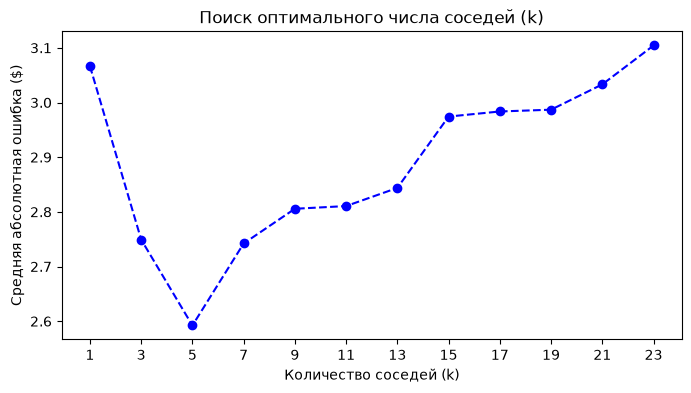

In [ ]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(xtrain, ytrain)
    ypred = knn.predict(xtest)
    errors.append(mean_absolute_error(ytest, ypred))

plt.figure(figsize=(8,4))
plt.plot(k_values, errors, marker = "o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка ($)")
plt.xticks(k_values)
plt.show


Был построен график с целью визуализации зависимости абсолютной ошбки от числа соседей. Наименьшая ошибка достигается при количестве соседей, равном 5.

Исследование метрик расстояния Минковского


In [ ]:
best_k = 5

#Обучаем модель с Евклидовой метрикой (p=2)
knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(xtrain, ytrain)
y_pred_ec = knn_euclidean.predict(xtest)

#Обучаем модель с Манхэттенской метрикой (p=1)
knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(xtrain, ytrain)
y_pred_man = knn_manhattan.predict(xtest)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2):     MAE = S{mean_absolute_error(ytest, y_pred_ec):,.2f} | R2 = {r2_score(ytest, y_pred_ec):,.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = S{mean_absolute_error(ytest, y_pred_man):,.2f} | R2 = {r2_score(ytest, y_pred_man):,.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2):     MAE = S2.59 | R2 = 0.72
Манхэттенское расстояние (p=1): MAE = S2.71 | R2 = 0.71


Сравнение метрик расстояния показывет, что более высокий показатель R2 при более низком MAE достигается при использовании Евклидова расстояния.

Регрессия Надарая-Ватсона

In [ ]:
gamma_values = np.logspace(-2,1 , 30)
best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(xtest, xtrain, gamma=g)
    weights_normalized = weights/ weights.sum(axis = 1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, ytrain.values)

    r2 = r2_score(ytest, y_pred_nw)
    mae = mean_absolute_error(ytest, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.2f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 3.04
Лучшее R2: 0.76
Лучшее MAE: $2.50


В данном модуле была произведена оптимизация для выявления оптимального параметра gamma, при котором достигаются лучшие параметры R2 и MAE.

Визуализация

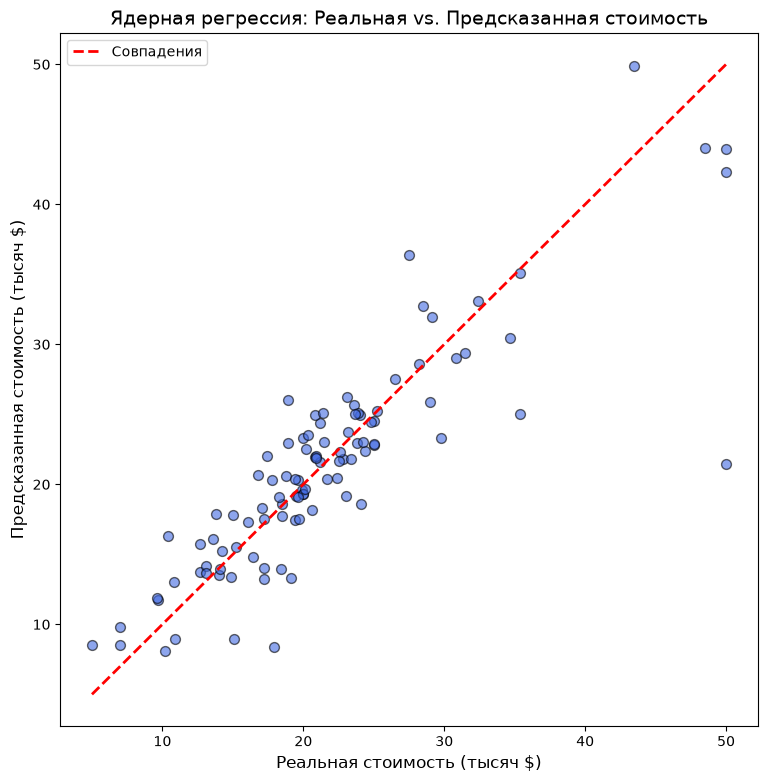

In [ ]:
plt.figure(figsize=(9,9))

plt.scatter(ytest, y_pred_nw, alpha = 0.6, color = "royalblue", edgecolor = "k", s = 50)

max_val = max(ytest.max(), y_pred_nw.max())
min_val = min(ytest.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальная vs. Предсказанная стоимость", fontsize = 14)
plt.xlabel("Реальная стоимость (тысяч $)", fontsize=12)
plt.ylabel("Предсказанная стоимость (тысяч $)", fontsize=12)
plt.legend()
plt.show()

В данном модуле строится график, отражающий точность предсказаний модели. Видно, что в основном предсказания достаточно близки к оптимальному результату. Однако можно заметить несколько выбросов. Они могут быть обусловлены как ошибкой модели, так и тем, что цена данных домов действительно отличалась от рыночной.